In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from numpy import array
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense, LSTM
import numpy as np
from sklearn.metrics import mean_squared_error

2025-11-19 23:26:45.488762: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-19 23:26:45.501318: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-19 23:26:47.458231: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-19 23:26:50.403649: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To tur

,Unnamed: 0,timestamp,DATE,TIME,DOY,ASY-D,ASY-H,SYM-D,SYM-H
0,3201120,2013-02-01 00:00:00,2013-02-01,00:00:00.000,32,15.0,34.0,0.0,-10.0
1,3201121,2013-02-01 00:01:00,2013-02-01,00:01:00.000,32,14.0,34.0,0.0,-10.0
2,3201122,2013-02-01 00:02:00,2013-02-01,00:02:00.000,32,13.0,34.0,0.0,-10.0
3,3201123,2013-02-01 00:03:00,2013-02-01,00:03:00.000,32,13.0,35.0,0.0,-10.0
4,3201124,2013-02-01 00:04:00,2013-02-01,00:04:00.000,32,13.0,35.0,0.0,-10.0


Representacion de columnas:
    SYM-H (Symmetric H-component): Representa el promedio mundial de la perturbación del campo magnético en el ecuador terrestre.
    Valores negativos fuertes indican una Tormenta Geomagnética. Cuanto más negativo es el valor (ej: -100 nT, -200 nT), más intensa es la tormenta. Es similar al famoso índice Dst pero con mayor resolución temporal (cada minuto).

    SYM-D (Symmetric D-component): Mide la componente "D" (Declinación) de la parte simétrica del campo. Generalmente es menos relevante que la H para medir la intensidad de una tormenta.

    ASY-H (Asymmetric H-component): Mide la asimetría del campo magnético (la diferencia entre el lado de día y el lado de noche de la Tierra). Picos altos en ASY-H suelen indicar el inicio de perturbaciones o "sub-tormentas" que inyectan energía a la magnetosfera.

    ASY-D (Asymmetric D-component): La asimetría en la componente de declinación.

In [ ]:
mediciones = pd.read_csv('sym_h_reduced.csv')
mediciones.head()

,Unnamed: 0,timestamp,DATE,TIME,DOY,ASY-D,ASY-H,SYM-D,SYM-H
0,3201120,2013-02-01 00:00:00,2013-02-01,00:00:00.000,32,15.0,34.0,0.0,-10.0
1,3201121,2013-02-01 00:01:00,2013-02-01,00:01:00.000,32,14.0,34.0,0.0,-10.0
2,3201122,2013-02-01 00:02:00,2013-02-01,00:02:00.000,32,13.0,34.0,0.0,-10.0
3,3201123,2013-02-01 00:03:00,2013-02-01,00:03:00.000,32,13.0,35.0,0.0,-10.0
4,3201124,2013-02-01 00:04:00,2013-02-01,00:04:00.000,32,13.0,35.0,0.0,-10.0


In [ ]:
print(mediciones.info())
print("\n Cantidad de valores nulos por columna")
print(mediciones[mediciones.isna()].sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40320 entries, 0 to 40319
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  40320 non-null  int64  
 1   timestamp   40320 non-null  object 
 2   DATE        40320 non-null  object 
 3   TIME        40320 non-null  object 
 4   DOY         40320 non-null  int64  
 5   ASY-D       40320 non-null  float64
 6   ASY-H       40320 non-null  float64
 7   SYM-D       40320 non-null  float64
 8   SYM-H       40320 non-null  float64
dtypes: float64(4), int64(2), object(3)
memory usage: 2.8+ MB
None

 Cantidad de valores nulos por columna
Unnamed: 0    0.0
timestamp       0
DATE            0
TIME            0
DOY           0.0
ASY-D         0.0
ASY-H         0.0
SYM-D         0.0
SYM-H         0.0
dtype: object


    Analizar los datos de la serie de tiempo (máximo, mínimo, existencia de datos
    faltantes, media, mediana, etc.)

In [ ]:
df_descripcion = mediciones.describe().iloc[:, 1:]

columnas = mediciones.columns[4:]

medianas = mediciones[columnas].median()
modas = mediciones[columnas].mode().iloc[0]

df_mediana = pd.DataFrame(medianas).T
df_mediana.index = ["median"]

df_moda = pd.DataFrame(modas).T
df_moda.index = ["mode"]

df_descripcion = pd.concat([df_mediana, df_moda, df_descripcion])

df_descripcion

,DOY,ASY-D,ASY-H,SYM-D,SYM-H
median,45.500000,12.000000,15.000000,-1.000000,-8.000000
mode,32.000000,10.000000,12.000000,-1.000000,-7.000000
count,40320.000000,40320.000000,40320.000000,40320.000000,40320.000000
mean,45.500000,14.099554,16.708358,-1.149479,-8.146478
std,8.077847,7.907772,9.462086,2.447383,9.760388
min,32.000000,1.000000,1.000000,-13.000000,-45.000000
25%,38.750000,9.000000,10.000000,-2.000000,-14.000000
50%,45.500000,12.000000,15.000000,-1.000000,-8.000000
75%,52.250000,17.000000,21.000000,0.000000,-1.000000
max,59.000000,60.000000,82.000000,7.000000,16.000000


    Plotear la serie de tiempo para su análisis visual.

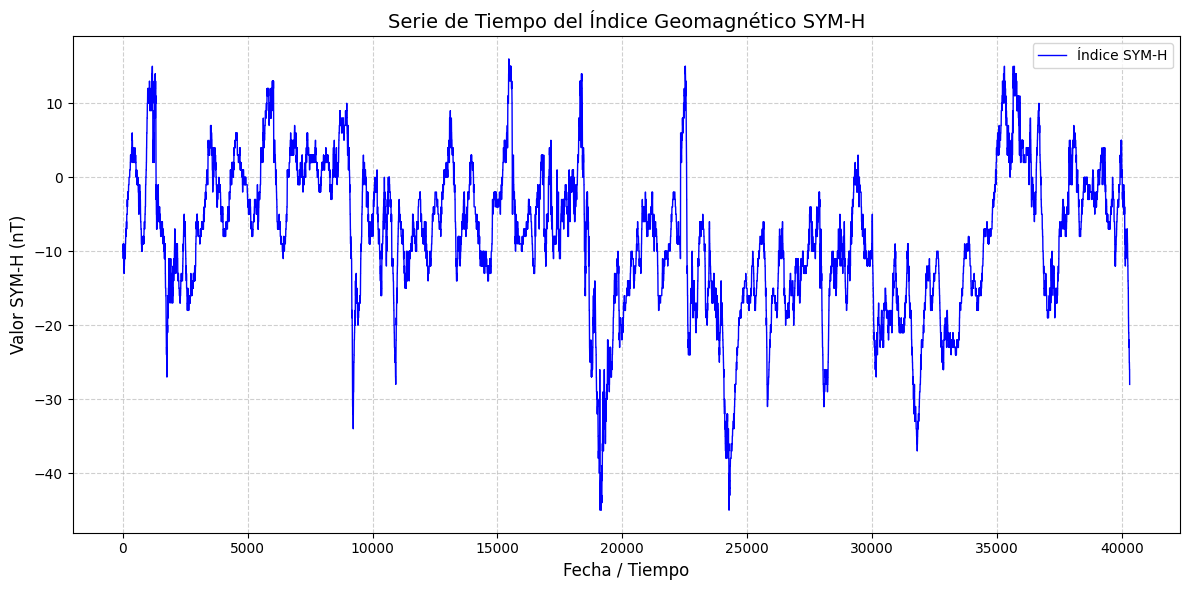

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(mediciones.index, mediciones['SYM-H'], label='Índice SYM-H', color='blue', linewidth=1)

# Añadir títulos y etiquetas
plt.title('Serie de Tiempo del Índice Geomagnético SYM-H', fontsize=14)
plt.xlabel('Fecha / Tiempo', fontsize=12)
plt.ylabel('Valor SYM-H (nT)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Mostrar el gráfico
plt.tight_layout()
plt.show()

In [ ]:
'''
import matplotlib.pyplot as plt

mediciones['timestamp'] = pd.to_datetime(mediciones['timestamp'])
mediciones = mediciones.sort_values('timestamp')

columnas = ['DOY', 'ASY-D', 'ASY-H', 'SYM-D', 'SYM-H']

fig, axs = plt.subplots(len(columnas), 1, figsize=(12, 10), sharex=True)

for i, col in enumerate(columnas):
    axs[i].plot(mediciones['timestamp'], mediciones[col], color=f'C{i}')
    axs[i].set_title(col)
    axs[i].grid(True)
    axs[i].set_ylabel(col)

plt.xlabel("Fecha y hora")
plt.tight_layout()
plt.show()
'''


'\nimport matplotlib.pyplot as plt\n\nmediciones[\'timestamp\'] = pd.to_datetime(mediciones[\'timestamp\'])\nmediciones = mediciones.sort_values(\'timestamp\')\n\ncolumnas = [\'DOY\', \'ASY-D\', \'ASY-H\', \'SYM-D\', \'SYM-H\']\n\nfig, axs = plt.subplots(len(columnas), 1, figsize=(12, 10), sharex=True)\n\nfor i, col in enumerate(columnas):\n    axs[i].plot(mediciones[\'timestamp\'], mediciones[col], color=f\'C{i}\')\n    axs[i].set_title(col)\n    axs[i].grid(True)\n    axs[i].set_ylabel(col)\n\nplt.xlabel("Fecha y hora")\nplt.tight_layout()\nplt.show()\n'

    
    Desarrollar una función que permita la selección de un intervalo de la serie de
    tiempo (esto puede servir para tomar una parte de la serie de tiempo para su
    análisis).

In [ ]:
def seleccionar_intervalo(df, columna_tiempo, inicio, fin):

    inicio = pd.to_datetime(inicio)
    fin = pd.to_datetime(fin)

    filtro = (df[columna_tiempo] >= inicio) & (df[columna_tiempo] <= fin)

    return df.loc[filtro]


In [ ]:

_inicio = pd.to_datetime('2013-02-01')
_fin = pd.to_datetime('2013-02-02')

df_con_fechas_seleccionadas = seleccionar_intervalo(mediciones, 'timestamp', _inicio , _fin)
df_con_fechas_seleccionadas.head(), df_con_fechas_seleccionadas.tail()

(   Unnamed: 0           timestamp        DATE          TIME  DOY  ASY-D  \
 0     3201120 2013-02-01 00:00:00  2013-02-01  00:00:00.000   32   15.0   
 1     3201121 2013-02-01 00:01:00  2013-02-01  00:01:00.000   32   14.0   
 2     3201122 2013-02-01 00:02:00  2013-02-01  00:02:00.000   32   13.0   
 3     3201123 2013-02-01 00:03:00  2013-02-01  00:03:00.000   32   13.0   
 4     3201124 2013-02-01 00:04:00  2013-02-01  00:04:00.000   32   13.0   
 
    ASY-H  SYM-D  SYM-H  
 0   34.0    0.0  -10.0  
 1   34.0    0.0  -10.0  
 2   34.0    0.0  -10.0  
 3   35.0    0.0  -10.0  
 4   35.0    0.0  -10.0  ,
       Unnamed: 0           timestamp        DATE          TIME  DOY  ASY-D  \
 1436     3202556 2013-02-01 23:56:00  2013-02-01  23:56:00.000   32    8.0   
 1437     3202557 2013-02-01 23:57:00  2013-02-01  23:57:00.000   32    8.0   
 1438     3202558 2013-02-01 23:58:00  2013-02-01  23:58:00.000   32    8.0   
 1439     3202559 2013-02-01 23:59:00  2013-02-01  23:59:00.000   32 

    Desarrollar una función que permita dividir los datos en datos de entrenamiento
    y datos de testeo.

In [ ]:


def dividir_train_test(df, columna, proporcion_train=0.8):

    data = df[columna]
    proporcion_test = 1 - proporcion_train
    train, test = train_test_split(data, test_size=0.2, shuffle=False)

    return train, test


    Desarrollar una función sliding window que permite acomodar la serie de tiempo
    en cantidad de pasos de entrada y pasos de salida variables (esto es un
    requisitos para el acomodamiento de datos antes de ingresar al modelado).

    La misma habilita el Aprendizaje Supervisado: Convierte datos temporales en el formato estándar (X, y)que necesitan el 99% de los algoritmos (Redes Neuronales, Random Forest, SVM, etc.). Sin esto, no puedes usarlos. Captura Patrones Locales, la misma es excelente para detectar patrones que se repiten a corto plazo (ej: "siempre que el índice baja rápido durante 3 horas, luego sube un poco") y es flexible, puedo ajustar el tamaño de la ventana.¿Quieres predecir en base a la última hora? Ventana pequeña.¿En base al último día? Ventana grande.

    Pérdida de Datos Iniciales: Si tu ventana es de 24 horas, pierdes las primeras 24 horas de tu base de datos (porque no tienen "pasado" suficiente para llenar la ventana).
    Aumento de Dimensionalidad: Si tu ventana es muy grande (ej: 1000 pasos atrás), tu matriz de entrada se vuelve enorme, lo que hace el entrenamiento más lento y pesado.
    "Ceguera" a Largo Plazo (si la ventana es chica): Si usas una ventana de 1 hora para predecir el clima, el modelo no sabrá si es invierno o verano (tendencia anual), porque su visión está limitada a esa pequeña ventana.

    Se la usa cuando, quieras usar algoritmos de Machine Learning (Random Forest, XGBoost) o Deep Learning (CNN, LSTM, MLP) para predecir series de tiempo. Es un paso obligatorio.
    Tus datos tengan autocorrelación: Es decir, que el valor de "ahora" dependa fuertemente de lo que pasó hace un rato (como el índice SYM-H, el precio de acciones, o la temperatura).


In [ ]:


def dividir_secuencia(secuencia, pasos_entrada, pasos_salida):

    X, y = list(), list()

    for i in range(len(secuencia)):

        fin_entrada = i + pasos_entrada # índice donde termina la ventana de entrada
        fin_salida = fin_entrada + pasos_salida # índice donde termina la ventana de salida


        if fin_salida > len(secuencia):
            break # si nos pasamos del final de la secuencia, cortamos el bucle

        ventana_entrada = secuencia[i:fin_entrada]
        ventana_salida = secuencia[fin_entrada:fin_salida]

        X.append(ventana_entrada)
        y.append(ventana_salida)

    return array(X), array(y)


In [ ]:
train, test = dividir_train_test(mediciones, 'ASY-D')
train.shape

(32256,)

In [ ]:

scaler = MinMaxScaler()
train = scaler.fit_transform(train.values.reshape(-1, 1))
test = scaler.transform(test.values.reshape(-1, 1))

In [ ]:
print (train)

[[0.23728814]
 [0.22033898]
 [0.20338983]
 ...
 [0.11864407]
 [0.11864407]
 [0.11864407]]


In [ ]:
n_steps_in, n_steps_out = 5, 10
X, y = dividir_secuencia(train, n_steps_in, n_steps_out)

In [ ]:
print(X.shape)
print(y.shape)

(32242, 5, 1)
(32242, 10, 1)


In [ ]:
#armar modelo


model = Sequential()
model.add(LSTM(5, activation='tanh', input_shape=(n_steps_in, 1)))
model.add(Dense(n_steps_out))
model.compile(optimizer='adam', loss='mse')
history = model.fit(X, y, epochs=5, verbose=2, validation_split=0.2)

2025-11-19 23:26:52.164385: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/home/luxor14/.venvs/ipykernel-env/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
807/807 - 4s - 6ms/step - loss: 0.0065 - val_loss: 0.0013
Epoch 2/5
807/807 - 2s - 3ms/step - loss: 0.0012 - val_loss: 0.0013
Epoch 3/5
807/807 - 2s - 3ms/step - loss: 0.0011 - val_loss: 0.0012
Epoch 4/5
807/807 - 2s - 3ms/step - loss: 0.0011 - val_loss: 0.0012
Epoch 5/5
807/807 - 2s - 3ms/step - loss: 0.0010 - val_loss: 0.0011


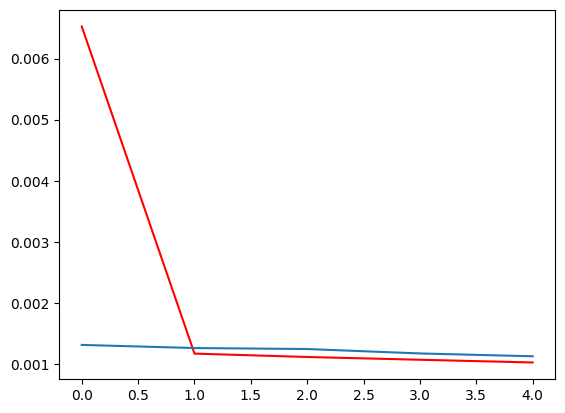

In [ ]:
plt.plot(history.history['loss'], color='red')
plt.plot(history.history['val_loss'])
plt.show()

    Desarrollar una función walking forward que permita predecir de acuerdo al
    sliding window definido sobre los datos de testeo. Calcular el error del modelo
    sobre los pasos que se puedan determinar según el walking forward.

In [ ]:


def walk_forward_predict(model, test, scaler, n_steps_in, n_steps_out):

    predicciones = []
    reales = []

    # cantidad de bloques posibles
    pasos = len(test) - n_steps_in - n_steps_out + 1

    for i in range(pasos):

        # tomar ventana deslizante
        X_input = test[i : i + n_steps_in].reshape(1, -1)

        # predecir n_steps_out valores
        yhat = model.predict(X_input, verbose=0)

        # desescalar predicción
        yhat_inv = scaler.inverse_transform(yhat)[0]

        predicciones.append(yhat_inv)

        # los valores reales para ese mismo bloque
        reales.append(
            scaler.inverse_transform(test[i + n_steps_in : i + n_steps_in + n_steps_out])
            .flatten()
        )

    predicciones = np.array(predicciones)
    reales = np.array(reales)

    # calcular error
    mse = mean_squared_error(reales.flatten(), predicciones.flatten())

    return predicciones, reales, mse


In [ ]:
def walk_forward_fast(model, data_scaled, scaler, n_steps_in, n_steps_out):
    preds = []
    reales = []

    i = 0
    while i + n_steps_in + n_steps_out <= len(data_scaled):

        ventana = data_scaled[i : i + n_steps_in]
        ventana = ventana.reshape(1, n_steps_in, 1)

        yhat_scaled = model.predict(ventana, verbose=0)

        yhat = scaler.inverse_transform(yhat_scaled.reshape(-1, 1))
        real = scaler.inverse_transform(
            data_scaled[i + n_steps_in : i + n_steps_in + n_steps_out].reshape(-1, 1)
        )

        preds.append(yhat)
        reales.append(real)

        i += n_steps_out

    # Convertir listas de arrays en un solo array
    preds_all = np.vstack(preds)
    reales_all = np.vstack(reales)

    from sklearn.metrics import mean_squared_error
    mse = mean_squared_error(reales_all, preds_all)

    return preds_all, reales_all, mse


In [ ]:
preds, reales, mse = walk_forward_fast(model, test, scaler, n_steps_in, n_steps_out)
print("MSE:", mse)


MSE: 2.222529897988166


    Desarrollar una función grid search (teniendo en cuenta al menos 2 hiper
    parámetros) que permitan generar diferentes modelos y elegir el mejor.

In [ ]:
def crear_modelo(n_neurons, n_steps_in, n_steps_out):
    model = Sequential()
    model.add(LSTM(n_neurons, activation='tanh', input_shape=(n_steps_in, 1)))
    model.add(Dense(n_steps_out))
    model.compile(optimizer='adam', loss='mse')
    return model

def grid_search_lstm(train_X, train_y, test_X, test_y,
                     neurons_list, epochs_list,
                     n_steps_in, n_steps_out):

    resultados = []
    mejor_mse = float('inf')
    mejor_modelo = None
    mejor_params = None

    for neu in neurons_list:
        for ep in epochs_list:

            print(f"\nProbando modelo: neuronas={neu}, epochs={ep}")

            model = crear_modelo(neu, n_steps_in, n_steps_out)
            model.fit(train_X, train_y, epochs=ep, verbose=0)

            # predecir test
            pred = model.predict(test_X, verbose=0)


            test_y_flat = test_y.reshape(test_y.shape[0], -1)
            pred_flat = pred.reshape(pred.shape[0], -1)

            mse = mean_squared_error(test_y_flat, pred_flat)

            print(f"   → MSE = {mse:.4f}")

            # guardar el mejor
            if mse < mejor_mse:
                mejor_mse = mse
                mejor_modelo = model
                mejor_params = (neu, ep)

    return mejor_modelo, mejor_params, mejor_mse, resultados

In [ ]:

X_train = X
y_train = y

X_test, y_test = dividir_secuencia(test, n_steps_in, n_steps_out)

neurons_list = [5, 10, 20]
epochs_list = [5, 10]

best_model, best_params, best_mse, resultados = grid_search_lstm(
    X_train, y_train,
    X_test, y_test,
    neurons_list, epochs_list,
    n_steps_in, n_steps_out
)

print("\nMEJOR MODELO ENCONTRADO:")
print("  Neuronas:", best_params[0])
print("  Epochs:", best_params[1])
print("  MSE:", best_mse)



Probando modelo: neuronas=5, epochs=5


/home/luxor14/.venvs/ipykernel-env/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


   → MSE = 0.0006

Probando modelo: neuronas=5, epochs=10


/home/luxor14/.venvs/ipykernel-env/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


   → MSE = 0.0005

Probando modelo: neuronas=10, epochs=5


...

   → MSE = 0.0005

Probando modelo: neuronas=20, epochs=5


/home/luxor14/.venvs/ipykernel-env/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


   → MSE = 0.0005

Probando modelo: neuronas=20, epochs=10


/home/luxor14/.venvs/ipykernel-env/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


   → MSE = 0.0005

MEJOR MODELO ENCONTRADO:
  Neuronas: 20
  Epochs: 10
  MSE: 0.0005187555167155012
